# Projection des coordonnées des sites d'essai clinique pour la cartographie avec PROC GPROJECT


## Résumé exécutif

Une équipe d'opérations cliniques doit tracer l'empreinte géographique d'un essai de Phase III multisite sur une carte plane. Ce notebook génère des coordonnées latitude/longitude synthétiques pour des sites d'essai regroupés autour de cinq pôles régionaux américains, puis utilise **PROC GPROJECT** pour convertir les coordonnées sphériques en valeurs cartésiennes X/Y à l'aide de trois méthodes de projection (Albers à aires égales, Lambert conforme avec parallèles standards personnalisés et recadrage régional, et gnomonique centrée sur les États-Unis continentaux), illustrant comment le choix de la projection et le recadrage affectent une carte de sites.


## Sources de données

| Jeu de données | Lignes | Variables clés | Description |
|---------|------|---------------|-------------|
| `trial_sites` | 60 (5 pôles x 12 sites) | `site_id` (ID $8), `region` ($9), `x` (longitude, degrés, est-positif), `y` (latitude, degrés), `enroll` (sujets inscrits), `segment` (id de segment de carte) | Emplacements synthétiques de sites d'essai clinique de Phase III dispersés autour de cinq pôles régionaux américains (Ouest, Midwest, Nord-Est, Sud, Sud-Est) en utilisant une variation `rand('normal')` et des inscriptions `rand('poisson')` |


# Projection des coordonnées des sites d'essai clinique avec PROC GPROJECT

Lorsqu'un promoteur mène un essai de Phase III géographiquement dispersé, le groupe des opérations cliniques souhaite souvent une carte unique montrant chaque site investigateur, dimensionné ou coloré selon l'inscription. Les emplacements des sites arrivent sous forme de **paires longitude/latitude**, mais une carte plane a besoin de **coordonnées planaires X/Y**. `PROC GPROJECT` effectue cette conversion sphérique-vers-cartésienne, en appliquant une projection cartographique afin que les distances et les surfaces soient rendues de façon sensée.

Dans ce notebook, nous allons :

1. Générer des coordonnées de sites synthétiques regroupées autour de cinq pôles régionaux américains.
2. Appliquer la projection **Albers à aires égales** par défaut.
3. Appliquer une projection **Lambert conforme** avec des parallèles standards personnalisés et un recadrage sur les États-Unis contigus.
4. Appliquer une projection **gnomonique** centrée sur le milieu géographique du pays, en conservant les coordonnées d'origine avec `ASIS`.

Tout est autonome : aucun fichier externe, aucun réseau.


## Étape 1 — Générer des coordonnées synthétiques de sites d'essai

Nous initialisons le générateur aléatoire avec `call streaminit` pour la reproductibilité, puis plaçons 12 sites autour de chacun des cinq pôles régionaux. Les longitudes sont stockées en degrés est-positif (négatives pour l'hémisphère occidental) et les latitudes en degrés. Chaque ligne porte aussi un nombre d'inscriptions et une variable `segment` (GPROJECT préserve les colonnes non-coordonnées à travers la projection).


In [1]:
DONNÉES trial_sites;
    APPELER streaminit(20260531);
    LONGUEUR site_id $8 region $9;
    /* Cinq centres de pôles régionaux américains : longitude (est+), latitude */
    TABLEAU clon[5]  _temporary_ (-122.3 -87.6 -71.1 -95.4 -80.2);
    TABLEAU clat[5]  _temporary_ (  37.8  41.9  42.4  29.8  25.8);
    TABLEAU rname[5] $9 _temporary_ ('Ouest' 'Midwest' 'Nord-Est' 'Sud' 'Sud-Est');

    FAIRE hub = 1 JUSQU_À 5;
        region = rname[hub];
        FAIRE s = 1 JUSQU_À 12;
            site_id = cats('S', ÉCRIRE(hub, z1.), ÉCRIRE(s, z2.));
            x       = clon[hub] + rand('normal', 0, 1.4);   /* longitude, degrés */
            y       = clat[hub] + rand('normal', 0, 1.0);   /* latitude,  degrés */
            enroll  = round(rand('poisson', 60));           /* sujets inscrits   */
            segment = 1;
            SORTIE;
        FIN;
    FIN;
    SUPPRIMER hub s;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=trial_sites(obs=10) ÉTIQUETTE;
    ÉTIQUETTE site_id="ID du site" region="Région" x="Longitude" y="Latitude"
          enroll="Inscrits" segment="Segment";
    TITRE "Échantillon de sites d'essai clinique synthétiques (lon/lat non projetées)";
EXÉCUTER;

                       Échantillon de sites d'essai clinique synthétiques (lon/lat non projetées)                       

  Obs  ID du site   Région        Longitude       Latitude  Inscrits  Segment
    1  S101        Ouest    -121.6437232216  37.7677668495        65        1
    2  S102        Ouest    -120.7384024716  37.5083287903        61        1
    3  S103        Ouest    -121.5133780284  37.8633933883        72        1
    4  S104        Ouest    -121.2086817368  38.7723343392        68        1
    5  S105        Ouest    -121.0499572297   37.175813806        54        1
    6  S106        Ouest    -124.0531899967   35.778231667        72        1
    7  S107        Ouest    -120.9370181032  39.0576714397        64        1
    8  S108        Ouest    -126.8495029747  36.6474680375        55        1
    9  S109        Ouest     -123.475989897  37.1427965254        56        1
   10  S110        Ouest     -122.579780071   36.931533678        57        1

... 50 more observa


NOTE: DATA trial_sites


NOTE: Wrote trial_sites (60 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC PRINT data=trial_sites

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Étape 2 — Projection Albers à aires égales par défaut

La projection conique **Albers** à aires égales est la valeur par défaut de GPROJECT et un choix judicieux pour une carte à l'échelle du pays où préserver la *surface relative* importe (par exemple, comparer la taille des bassins de recrutement régionaux).

Comme nos coordonnées sont stockées en **degrés** avec une **longitude est-positive**, nous précisons les options `DEGREE` et `EASTLONG`. L'instruction `ID` nomme la variable qui identifie de façon unique chaque unité ; les coordonnées planaires projetées sont réécrites dans `x` et `y` du jeu de données `OUT=`.


In [2]:
PROCÉDURE GPROJECT DONNÉES=trial_sites out=sites_albers
        DEGREE eastlong;
    id site_id;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=sites_albers(obs=10) ÉTIQUETTE;
    ÉTIQUETTE site_id="ID du site" region="Région" x="X projeté (Albers)"
          y="Y projeté (Albers)" enroll="Inscrits" segment="Segment";
    TITRE "Sites d'essai après projection équivalente Albers (X/Y planaires)";
EXÉCUTER;

                       Échantillon de sites d'essai clinique synthétiques (lon/lat non projetées)                       

                           Sites d'essai après projection équivalente Albers (X/Y planaires)                            

  Obs  ID du site   Région   X projeté (Albers)   Y projeté (Albers)  Inscrits  Segment
    1  S101        Ouest           -0.346124731         0.0516986079        65        1
    2  S102        Ouest          -0.3353644139         0.0440400181        61        1
    3  S103        Ouest          -0.3439609675         0.0528501365        72        1
    4  S104        Ouest          -0.3357513354          0.067213083        68        1
    5  S105        Ouest          -0.3410170723         0.0394882801        54        1
    6  S106        Ouest          -0.3879364507         0.0273340733        72        1
    7  S107        Ouest          -0.3309127579         0.0711146305        64        1
    8  S108        Ouest          -0.4204191205     


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 60 observations projected (project=ALBERS)
NOTE: PROC PRINT data=sites_albers

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Étape 3 — Projection conforme de Lambert avec parallèles personnalisés et recadrage

La projection conique conforme de **Lambert** préserve la *forme et les angles locaux*, ce qui est préférable lorsque la carte sert à la navigation ou à la superposition de caractéristiques directionnelles. Pour les États-Unis contigus, des parallèles standards proches de 33° N et 45° N sont conventionnels, nous les fixons donc explicitement avec `PARALLEL1=` et `PARALLEL2=`.

Nous limitons aussi la carte à la fenêtre des États-Unis contigus à l'aide des options de recadrage `LATMIN=`, `LATMAX=`, `LONGMIN=` et `LONGMAX=`. Tout site situé hors de cette zone latitude/longitude est écarté avant la projection, donc le nombre d'observations en sortie peut être inférieur à celui en entrée.


In [3]:
PROCÉDURE GPROJECT DONNÉES=trial_sites out=sites_lambert
        project=lambert DEGREE eastlong
        parallel1=33 parallel2=45
        latmin=24 latmax=50 longmin=-125 longmax=-66;
    id site_id;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=sites_lambert(obs=10) ÉTIQUETTE;
    ÉTIQUETTE site_id="ID du site" region="Région" x="X projeté (Lambert)"
          y="Y projeté (Lambert)" enroll="Inscrits" segment="Segment";
    TITRE "Sites d'essai après projection conforme de Lambert (limités aux États-Unis contigus)";
EXÉCUTER;

                           Sites d'essai après projection équivalente Albers (X/Y planaires)                            

                  Sites d'essai après projection conforme de Lambert (limités aux États-Unis contigus)                  

  Obs  ID du site   Région   X projeté (Lambert)   Y projeté (Lambert)  Inscrits  Segment
    1  S101        Ouest           -0.3473024124          0.0279382533        65        1
    2  S102        Ouest           -0.3365626234          0.0201991247        61        1
    3  S103        Ouest           -0.3451238364          0.0290365995        72        1
    4  S104        Ouest           -0.3367881094          0.0430616123        68        1
    5  S105        Ouest           -0.3422656751          0.0158037156        54        1
    6  S106        Ouest           -0.3894389642          0.0046370991        72        1
    7  S107        Ouest           -0.3319086764          0.0468276119        64        1
    8  S109        Ouest           -


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 58 observations projected (project=LAMBERT)
NOTE: PROC PRINT data=sites_lambert

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Étape 4 — Projection gnomonique centrée sur le pays, conservant les coordonnées d'origine

La projection azimutale **gnomonique** rend chaque grand cercle sous forme de ligne droite, ce qui est utile lorsqu'on veut raisonner sur le plus court chemin entre deux sites (par exemple, planifier l'itinéraire de visite d'un moniteur d'étude). La distorsion croît avec la distance au pôle de projection, nous centrons donc le pôle sur le milieu géographique des États-Unis continentaux avec `POLELAT=39` et `POLELONG=-98`.

L'option `ASIS` indique à GPROJECT de conserver les coordonnées non projetées d'origine en plus des valeurs projetées, donc le jeu de données en sortie porte à la fois les `X`/`Y` planaires et les `LONG`/`LAT` d'origine — pratique pour rejoindre les métriques d'inscription à l'un ou l'autre espace de coordonnées.

L'instruction `PARMENTRY` est présentée comme une autre façon de fournir les paramètres de projection sous forme de remplacements clé=valeur.


In [4]:
PROCÉDURE GPROJECT DONNÉES=trial_sites out=sites_gnomon
        project=gnomon DEGREE eastlong asis
        polelat=39 polelong=-98;
    id site_id;
    parmentry polelat=39 polelong=-98;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=sites_gnomon(obs=10) ÉTIQUETTE;
    ÉTIQUETTE site_id="ID du site" region="Région" x="X projeté (gnomonique)"
          y="Y projeté (gnomonique)" enroll="Inscrits" segment="Segment"
          long="Longitude d'origine" lat="Latitude d'origine";
    TITRE "Sites d'essai après projection gnomonique (ASIS conserve LONG/LAT d'origine)";
EXÉCUTER;

                  Sites d'essai après projection conforme de Lambert (limités aux États-Unis contigus)                  

                      Sites d'essai après projection gnomonique (ASIS conserve LONG/LAT d'origine)                      

  Obs  ID du site   Région   X projeté (gnomonique)   Y projeté (gnomonique)  Inscrits  Segment  Longitude d'origine  Latitude d'origine
    1  S101        Ouest              -0.3343477981             0.0213614461        65        1      -121.6437232216       37.7677668495
    2  S102        Ouest              -0.3221611694             0.0134152735        61        1      -120.7384024716       37.5083287903
    3  S103        Ouest              -0.3319480803             0.0225717184        72        1      -121.5133780284       37.8633933883
    4  S104        Ouest              -0.3230855797             0.0375741352        68        1      -121.2086817368       38.7723343392
    5  S105        Ouest              -0.3283677206             0.00863


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 60 observations projected (project=GNOMON)
NOTE: PROC PRINT data=sites_gnomon

NOTE: PROC PRINT completed: 10 observations printed, 8 variables


## Étape 5 — Représenter la carte des sites projetés

Le but même de la projection est de tracer la carte. Nous transmettons directement le jeu de données `OUT=` d'Albers à **PROC SGPLOT**, en traçant les `X`/`Y` planaires et en colorant chaque marqueur par `region`. Comme la projection a préservé la géographie relative, les cinq pôles de regroupement atterrissent dans leurs coins attendus du graphique — Ouest à gauche, Nord-Est en haut à droite, Sud et Sud-Est en bas — offrant aux opérations cliniques l'empreinte fidèle en surface décrite dans le résumé exécutif.


                      Sites d'essai après projection gnomonique (ASIS conserve LONG/LAT d'origine)                      




NOTE: PROC SGPLOT data=sites_albers

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


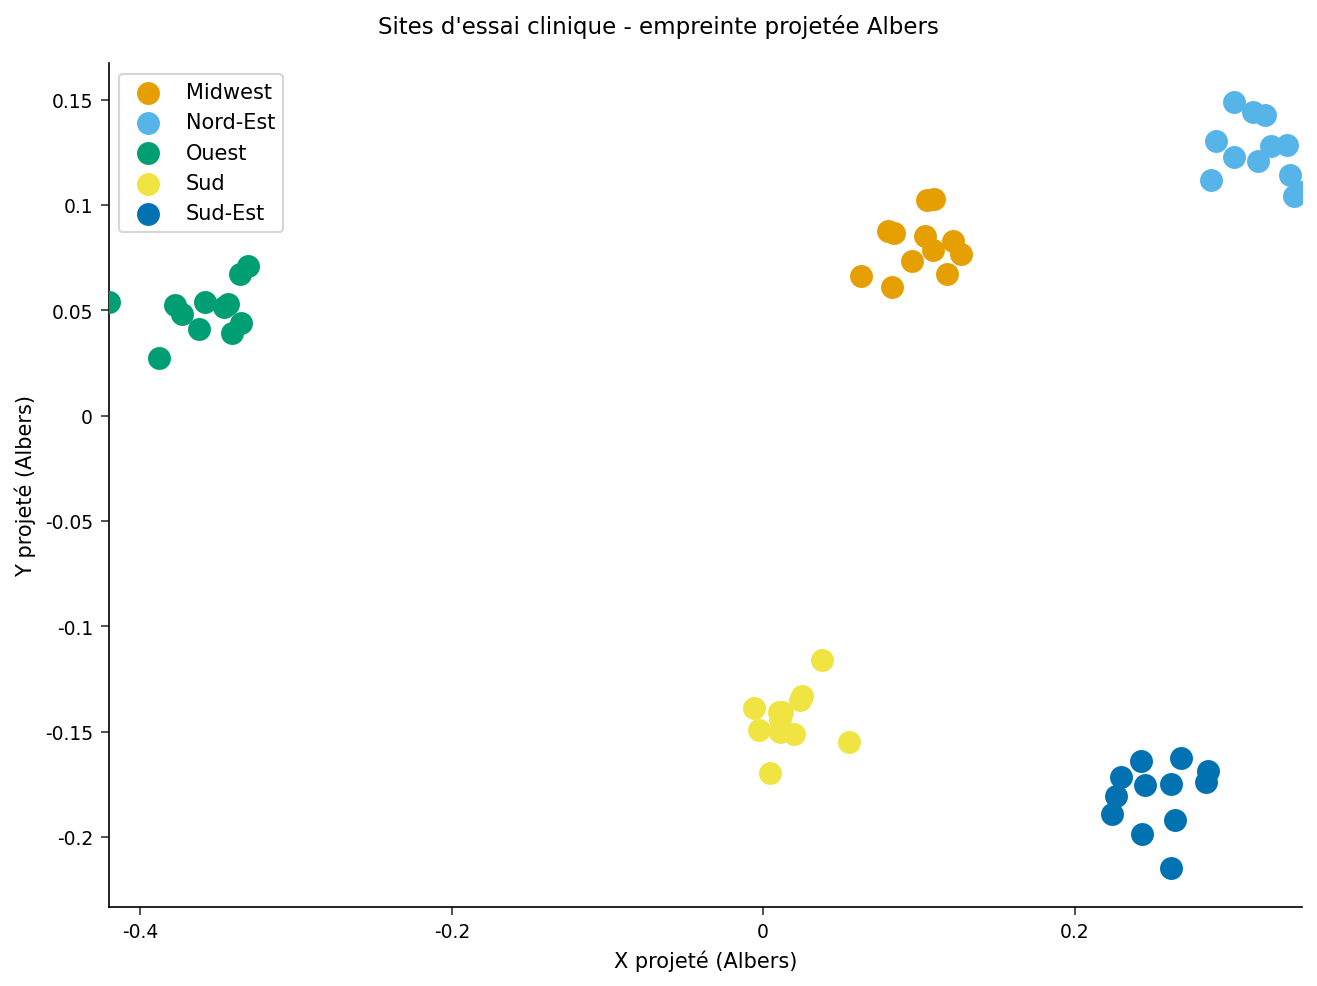

In [5]:
PROCÉDURE SGPLOT DONNÉES=sites_albers;
    SCATTER x=x y=y / GROUPE=region
            MARKERATTRS=(SYMBOL=circlefilled size=10);
    XAXIS ÉTIQUETTE="X projeté (Albers)";
    YAXIS ÉTIQUETTE="Y projeté (Albers)";
    TITRE "Sites d'essai clinique - empreinte projetée Albers";
EXÉCUTER;

## Interprétation des résultats

- **Albers (étape 2)** a transformé les 60 sites en coordonnées planaires tout en préservant la surface relative — les regroupements Ouest, Midwest, Nord-Est, Sud et Sud-Est conservent leur empreinte spatiale proportionnelle, ce qui constitue la bonne base pour une carte de densité d'inscription fidèle en surface.
- **Lambert avec recadrage (étape 3)** a préservé la forme locale et, en appliquant la fenêtre `LATMIN`/`LATMAX`/`LONGMIN`/`LONGMAX`, a écarté les sites synthétiques dispersés hors des États-Unis contigus — ici le nombre est passé de 60 à 58, si bien que les deux coordonnées hors grille qui auraient sinon étiré la carte ont été retirées avant la projection.
- **Gnomonique avec `ASIS` (étape 4)** a centré la projection sur l'intérieur du pays et, grâce à `ASIS`, a produit un jeu de données portant à la fois les `X`/`Y` projetées et les `LONG`/`LAT` d'origine. Les grands cercles apparaissent comme des lignes droites, donc les distances en ligne droite sur cette carte se rapprochent des plus courts chemins réels entre sites.
- **L'empreinte représentée (étape 5)** confirme que la projection a fonctionné : tracer les `X`/`Y` d'Albers par région place les cinq pôles de regroupement dans leurs coins attendus du plan, l'empreinte de site fidèle en surface promise par le résumé exécutif.

**À retenir pour les opérations cliniques :** la projection n'est pas cosmétique. Choisissez **Albers** pour une densité d'inscription fidèle en surface, **Lambert** pour des superpositions fidèles en forme avec recadrage régional, et **gnomonique** lorsque la distance de déplacement site-à-site guide l'analyse. Comme le montre l'étape 5, le jeu de données `OUT=` projeté s'intègre directement à PROC SGPLOT (ou PROC GMAP) pour représenter la carte finale des sites.
